# 15 — Corpus Frequency Analysis

**Question:** Are blind model answer biases explained by VQA training-set answer frequencies?

McCoy et al. (2024) argue LLMs produce outputs proportional to corpus frequency. If true, blind VLM outputs should mirror the VQA v2.0 training answer distribution. We test this directly by correlating blind model answer distributions with train/val ground-truth frequencies per question type.

In [1]:
import json
import sys
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr

ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'analysis'))

VQA_DIR = ROOT / 'dataset' / 'vqa'
TRAIN_ANNOT = VQA_DIR / 'v2_mscoco_train2014_annotations.json'
VAL_ANNOT   = VQA_DIR / 'v2_mscoco_val2014_annotations.json'

print(f"ROOT: {ROOT}")
print(f"Train annotations: {TRAIN_ANNOT.exists()}")
print(f"Val annotations:   {VAL_ANNOT.exists()}")

ROOT: /home/david/Desktop/yuna/HPA
Train annotations: True
Val annotations:   True


## 1. Load VQA v2.0 annotations (train + val)

In [2]:
def load_annotations(path):
    with open(path) as f:
        data = json.load(f)
    return data['annotations']

train_annot = load_annotations(TRAIN_ANNOT)
val_annot   = load_annotations(VAL_ANNOT)
all_annot   = train_annot + val_annot

print(f"Train: {len(train_annot):,} | Val: {len(val_annot):,} | Combined: {len(all_annot):,}")

# Quick sanity: answer_type distribution
for label, annots in [("Train", train_annot), ("Val", val_annot)]:
    types = Counter(a['answer_type'] for a in annots)
    print(f"\n{label} answer_type distribution:")
    for t, c in types.most_common():
        print(f"  {t:10s}  {c:7,d}  ({c/len(annots)*100:.1f}%)")

Train: 443,757 | Val: 214,354 | Combined: 658,111

Train answer_type distribution:
  other       219,269  (49.4%)
  yes/no      166,882  (37.6%)
  number       57,606  (13.0%)

Val answer_type distribution:
  other       105,679  (49.3%)
  yes/no       80,541  (37.6%)
  number       28,134  (13.1%)


## 2. Build answer frequency tables per question type

For each `answer_type` (yes/no, number, other), compute the probability distribution over answers in the training set. This is the "corpus frequency" that McCoy's framework predicts models should replicate.

In [3]:
def build_answer_freq(annots, answer_key='multiple_choice_answer'):
    """Build {answer_type: {answer: count}} from annotations."""
    freq = {}
    for a in annots:
        atype = a['answer_type']
        ans = a[answer_key].lower().strip()
        if atype not in freq:
            freq[atype] = Counter()
        freq[atype][ans] += 1
    return freq

def freq_to_prob(counter):
    """Convert Counter to probability dict."""
    total = sum(counter.values())
    return {k: v / total for k, v in counter.items()}

train_freq = build_answer_freq(train_annot)
val_freq   = build_answer_freq(val_annot)
all_freq   = build_answer_freq(all_annot)

# Show top answers per type
for atype in ['yes/no', 'number', 'other']:
    print(f"\n=== {atype} — Train top 10 ===")
    total = sum(train_freq[atype].values())
    for ans, cnt in train_freq[atype].most_common(10):
        print(f"  {ans:20s}  {cnt:6,d}  ({cnt/total*100:5.1f}%)")


=== yes/no — Train top 10 ===
  yes                   84,615  ( 50.7%)
  no                    82,263  ( 49.3%)
  africa                     1  (  0.0%)
  not                        1  (  0.0%)
  cutting apples             1  (  0.0%)
  cups                       1  (  0.0%)

=== number — Train top 10 ===
  1                     12,520  ( 21.7%)
  2                     12,194  ( 21.2%)
  3                      6,527  ( 11.3%)
  0                      4,860  (  8.4%)
  4                      4,112  (  7.1%)
  5                      2,359  (  4.1%)
  6                      1,452  (  2.5%)
  10                       972  (  1.7%)
  7                        937  (  1.6%)
  8                        907  (  1.6%)

=== other — Train top 10 ===
  white                  8,915  (  4.1%)
  blue                   5,455  (  2.5%)
  red                    5,201  (  2.4%)
  black                  5,066  (  2.3%)
  brown                  3,814  (  1.7%)
  green                  3,750  (  1.7%)
  yell

## 3. Load blind model outputs from our 1K questions

Load the model response CSVs and compute answer distributions per question type under blind conditions.

In [4]:
# Load 1K VQA questions (has answer_type, question_type, ground truth)
vqa1k = json.load(open(VQA_DIR / 'vqav2_1k_val.json'))
df_q = pd.DataFrame(vqa1k)
print(f"VQA 1K: {len(df_q)} questions")
print(f"answer_type distribution:\n{df_q['answer_type'].value_counts()}")
print(f"\nquestion_type top 10:\n{df_q['question_type'].value_counts().head(10)}")

# Build qid -> answer_type lookup
qid_to_atype = dict(zip(df_q['question_id'], df_q['answer_type']))
qid_to_qtype = dict(zip(df_q['question_id'], df_q['question_type']))

VQA 1K: 1000 questions
answer_type distribution:
answer_type
other     490
yes/no    388
number    122
Name: count, dtype: int64

question_type top 10:
question_type
is the               88
how many             85
what                 84
what color is the    59
what is the          52
is this a            41
is this              40
none of the above    37
what is              31
what kind of         24
Name: count, dtype: int64


In [5]:
# Load blind model outputs from JSONL files (full 1K, variant C = original question)
from analysis.utils.model_registry import default_all_models, backbone_models, backbone_think_models, MODEL_TYPE
from analysis.utils.vqa import preprocess_answer

def load_all_model_answers(condition='_control_inst_blind'):
    """Load blind answers for all models. Returns {name: (group, {qid: answer})}."""
    models = {}
    all_m = default_all_models(ROOT)
    all_m.update(backbone_models(ROOT))
    all_m.update(backbone_think_models(ROOT))

    for name, (base_dir, subdir) in all_m.items():
        jsonl = base_dir / subdir / f'vqa_1k{condition}.jsonl'
        if not jsonl.exists():
            continue
        group = MODEL_TYPE.get(name)
        if group is None:
            continue
        answers = {}
        for line in open(jsonl):
            ex = json.loads(line)
            qid = int(ex['question_id'])
            ga = ex.get('generated_answers', {})
            if ga:
                ans = preprocess_answer(ga.get('question', ''), strip_think=True)
            else:
                ans = preprocess_answer(ex.get('generated_answer', ''), strip_think=True)
            if ans:
                answers[qid] = ans
        if answers:
            models[name] = (group, answers)
    return models

all_models = load_all_model_answers('_control_inst_blind')
all_models_blind = load_all_model_answers('_control_blind')

print(f"inst_blind: {len(all_models)} models")
print(f"blind:      {len(all_models_blind)} models")
for g in sorted(set(grp for _, (grp, _) in all_models.items())):
    n = sum(1 for _, (grp, _) in all_models.items() if grp == g)
    print(f"  {g}: {n}")

inst_blind: 38 models
blind:      38 models
  VLM: 11
  VLM backbone decoder: 11
  standalone LLM: 11
  standalone LLM (think): 5


## 4. Compare model blind distributions vs training distributions

For each answer type, build the model's answer probability distribution across all 1K questions, then correlate with the VQA training set answer distribution.

In [6]:
def model_answer_dist(answers, answer_type):
    """Get answer distribution for a model, filtered by answer_type."""
    counter = Counter()
    for qid, ans in answers.items():
        if qid_to_atype.get(qid) == answer_type:
            counter[ans] += 1
    return counter

def correlate_distributions(model_counter, train_counter, top_k=20):
    """Correlate model answer distribution with training distribution."""
    top_model = {a for a, _ in model_counter.most_common(top_k)}
    top_train = {a for a, _ in train_counter.most_common(top_k)}
    vocab = top_model | top_train
    
    if len(vocab) < 3:
        return np.nan, np.nan, len(vocab)
    
    model_prob = freq_to_prob(model_counter)
    train_prob = freq_to_prob(train_counter)
    
    model_vec = [model_prob.get(a, 0) for a in sorted(vocab)]
    train_vec = [train_prob.get(a, 0) for a in sorted(vocab)]
    
    rho, p = spearmanr(model_vec, train_vec)
    return rho, p, len(vocab)

# Compute correlations per model per answer_type
rows = []
for model_name, (group, answers) in all_models.items():
    for atype in ['yes/no', 'number', 'other']:
        dist = model_answer_dist(answers, atype)
        if sum(dist.values()) < 10:
            continue
        for freq_label, freq_dict in [('train', train_freq), ('val', val_freq), ('train+val', all_freq)]:
            rho, p, n = correlate_distributions(dist, freq_dict[atype])
            rows.append({
                'model': model_name, 'group': group,
                'answer_type': atype, 'corpus': freq_label,
                'spearman_rho': rho, 'p_value': p, 'n_vocab': n
            })

df_corr = pd.DataFrame(rows)
print(f"Correlation table: {len(df_corr)} rows")
df_corr.head(10)

Correlation table: 342 rows


,model,group,answer_type,corpus,spearman_rho,p_value,n_vocab
0,Qwen3-VL-2B,VLM,yes/no,train,0.920000,0.009344,6
1,Qwen3-VL-2B,VLM,yes/no,val,0.920000,0.009344,6
2,Qwen3-VL-2B,VLM,yes/no,train+val,0.975309,0.000002,10
3,Qwen3-VL-2B,VLM,number,train,-0.114903,0.517580,34
4,Qwen3-VL-2B,VLM,number,val,-0.136038,0.442999,34
5,Qwen3-VL-2B,VLM,number,train+val,-0.119600,0.500490,34
6,Qwen3-VL-2B,VLM,other,train,-0.324294,0.065591,33
7,Qwen3-VL-2B,VLM,other,val,-0.345722,0.048760,33
8,Qwen3-VL-2B,VLM,other,train+val,-0.329693,0.060974,33
9,Qwen3-VL-4B,VLM,yes/no,train,0.920000,0.009344,6


## 5. Summary heatmap: Spearman rho (model vs train) by answer type

In [7]:
# Pivot: model x answer_type, using train corpus
pivot = df_corr[df_corr['corpus'] == 'train'].pivot_table(
    index=['group', 'model'], columns='answer_type', values='spearman_rho')
pivot = pivot[['yes/no', 'number', 'other']]
pivot = pivot.sort_values('group')

print("Spearman rho (model blind dist vs VQA train dist)")
print("=" * 60)
display(pivot.round(3))

Spearman rho (model blind dist vs VQA train dist)


answer_type                                   yes/no  number  other
group                  model                                       
VLM                    InternVL-1B             0.920  -0.208 -0.564
                       InternVL-2B             0.920  -0.082 -0.371
                       InternVL-8B             0.565   0.342  0.056
                       LLaVA-1.5-7B            0.042  -0.163 -0.279
                       LLaVA-Mistral           0.042  -0.143 -0.318
                       LLaVA-Vicuna            0.042  -0.237 -0.408
                       LLaVA-Vicuna-13B        0.920   0.044 -0.258
                       Qwen3-VL-2B             0.920  -0.115 -0.324
                       Qwen3-VL-32B           -0.201   0.115 -0.043
                       Qwen3-VL-4B             0.920  -0.042  0.115
                       Qwen3-VL-8B             0.042  -0.159  0.025
VLM backbone decoder   InternVL-1B (LM)        1.000   0.006 -0.022
                       InternVL-2B (LM)        1.000   0.183 -0.258
                       InternVL-8B (LM)        0.117   0.289 -0.044
                       LLaVA-1.5 (LM)          0.920   0.167  0.162
                       LLaVA-Mistral (LM)      1.000   0.077  0.028
                       LLaVA-Vicuna (LM)       1.000   0.138  0.051
                       LLaVA-Vicuna-13B (LM)   1.000   0.204  0.065
                       Qwen3-VL-2B (LM)        0.565   0.237 -0.185
                       Qwen3-VL-32B (LM)       1.000   0.317 -0.034
                       Qwen3-VL-4B (LM)        0.208   0.258  0.064
                       Qwen3-VL-8B (LM)        0.565   0.117 -0.014
standalone LLM         Mistral-7B             -0.770  -0.885 -0.891
                       Phi-3.5-mini           -0.172  -0.348 -0.407
                       Qwen2.5-7B             -0.854  -0.679 -0.884
                       Qwen2.5-7B-Instruct    -0.167   0.223  0.045
                       Qwen3-0.6B             -0.742  -0.575 -0.292
                       Qwen3-1.7B             -0.386  -0.267 -0.645
                       Qwen3-32B              -0.157   0.051 -0.028
                       Qwen3-4B               -0.174  -0.079  0.034
                       Qwen3-8B               -0.154   0.140 -0.110
                       Vicuna-13B             -0.156   0.034  0.055
                       Vicuna-7B              -0.165  -0.228 -0.629
standalone LLM (think) Qwen3-0.6B (think)     -0.742  -0.575 -0.292
                       Qwen3-1.7B (think)     -0.162  -0.011 -0.218
                       Qwen3-32B (think)      -0.162  -0.342 -0.089
                       Qwen3-4B (think)       -0.174  -0.079  0.034
                       Qwen3-8B (think)       -0.154   0.140 -0.110

## 6. Direct comparison: "no" bias and "0" bias vs training frequency

The key test: if blind biases come from training frequency, we'd expect:
- yes/no: ~50/50 (training is 50.7% yes, 49.3% no)
- number: "1" and "2" most common (training: 21.7% and 21.2%), not "0" (8.4%)

What do models actually produce?

In [8]:
# Yes/No: model "no" rate vs training "no" rate (49.3%)
print("=== Yes/No: % answering 'no' (training baseline: 49.3%) ===\n")
print(f"{'Model':40s} {'Group':28s} {'%no':>6s}  {'%yes':>6s}  {'n':>4s}")
print("-" * 85)
for model_name, (group, answers) in sorted(all_models.items(), key=lambda x: x[1][0]):
    dist = model_answer_dist(answers, 'yes/no')
    total = sum(dist.values())
    if total < 10:
        continue
    no_rate = dist.get('no', 0) / total * 100
    yes_rate = dist.get('yes', 0) / total * 100
    print(f"  {model_name:38s} {group:28s} {no_rate:5.1f}%  {yes_rate:5.1f}%  {total:4d}")

# Number: model "0" rate vs training "0" rate (8.4%)
print("\n\n=== Number: top answer (training: '1'=21.7%, '2'=21.2%, '0'=8.4%) ===\n")
print(f"{'Model':40s} {'Group':28s} {'%0':>6s}  {'%1':>6s}  {'%2':>6s}  {'n':>4s}")
print("-" * 100)
for model_name, (group, answers) in sorted(all_models.items(), key=lambda x: x[1][0]):
    dist = model_answer_dist(answers, 'number')
    total = sum(dist.values())
    if total < 10:
        continue
    r0 = dist.get('0', 0) / total * 100
    r1 = dist.get('1', 0) / total * 100
    r2 = dist.get('2', 0) / total * 100
    print(f"  {model_name:38s} {group:28s} {r0:5.1f}%  {r1:5.1f}%  {r2:5.1f}%  {total:4d}")

=== Yes/No: % answering 'no' (training baseline: 49.3%) ===

Model                                    Group                           %no    %yes     n
-------------------------------------------------------------------------------------
  Qwen3-VL-2B                            VLM                           86.6%   13.4%   388
  Qwen3-VL-4B                            VLM                           63.7%   36.3%   388
  Qwen3-VL-8B                            VLM                           54.0%   44.7%   387
  Qwen3-VL-32B                           VLM                           52.1%   40.2%   388
  LLaVA-1.5-7B                           VLM                           90.7%    8.0%   388
  LLaVA-Mistral                          VLM                           74.0%   24.7%   388
  LLaVA-Vicuna                           VLM                           83.0%   15.7%   388
  LLaVA-Vicuna-13B                       VLM                           67.5%   32.5%   388
  InternVL-1B                     

## 7. Visualization: Model vs Training answer distributions (side-by-side)

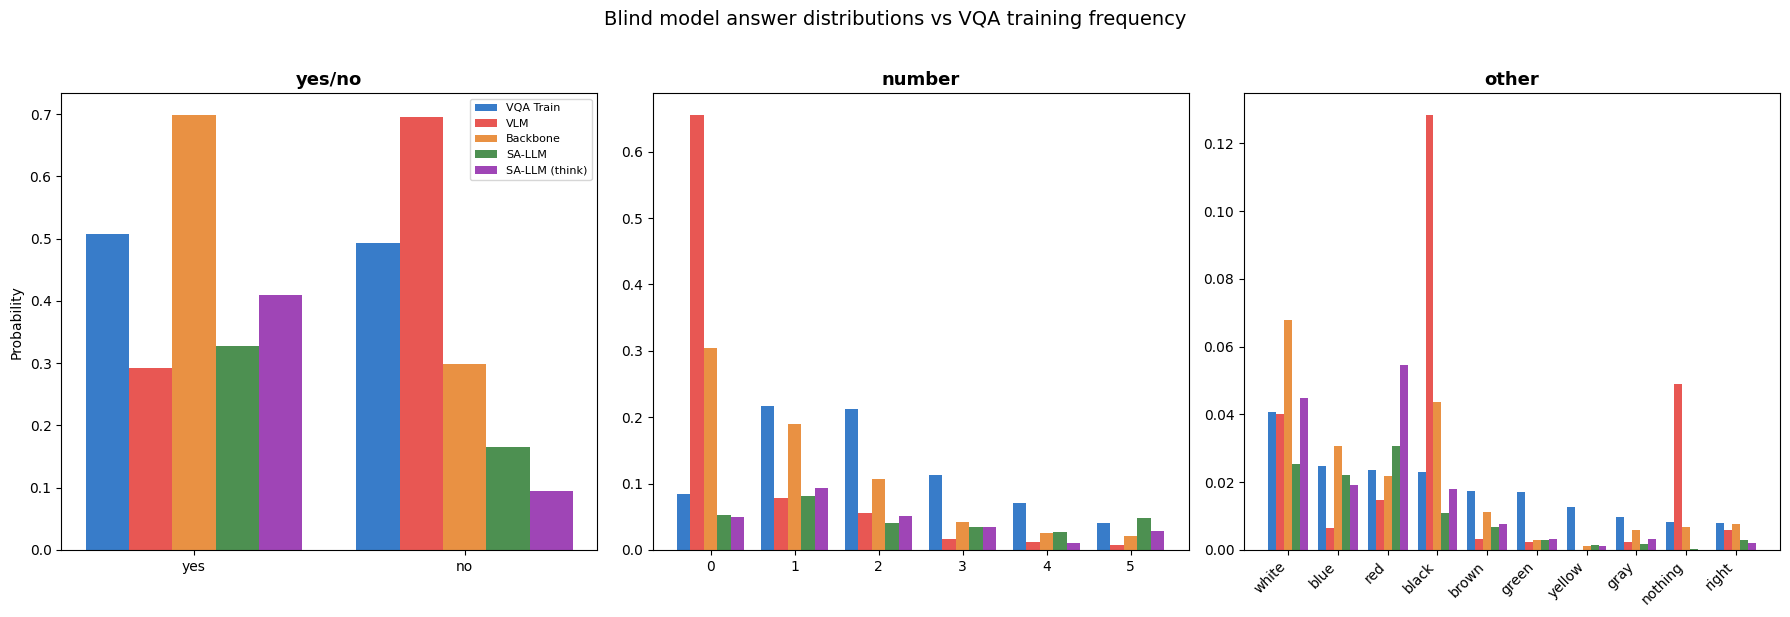

In [9]:
GROUP_COLORS = {
    'VLM': '#E53935', 'VLM backbone decoder': '#E67E22',
    'standalone LLM': '#2E7D32', 'standalone LLM (think)': '#8E24AA',
}
GROUP_SHORT = {
    'VLM': 'VLM', 'VLM backbone decoder': 'Backbone',
    'standalone LLM': 'SA-LLM', 'standalone LLM (think)': 'SA-LLM (think)',
}
GROUP_ORDER = ['VLM', 'VLM backbone decoder', 'standalone LLM', 'standalone LLM (think)']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, atype in enumerate(['yes/no', 'number', 'other']):
    ax = axes[idx]
    train_prob = freq_to_prob(train_freq[atype])
    if atype == 'yes/no':
        vocab = ['yes', 'no']
    elif atype == 'number':
        vocab = ['0', '1', '2', '3', '4', '5']
    else:
        vocab = [a for a, _ in train_freq[atype].most_common(10)]
    
    train_vals = [train_prob.get(a, 0) for a in vocab]
    
    group_sums = {g: Counter() for g in GROUP_ORDER}
    group_n = {g: 0 for g in GROUP_ORDER}
    for model_name, (group, answers) in all_models.items():
        dist = model_answer_dist(answers, atype)
        total = sum(dist.values())
        if total < 10:
            continue
        prob = freq_to_prob(dist)
        for a in vocab:
            group_sums[group][a] += prob.get(a, 0)
        group_n[group] += 1
    
    x = np.arange(len(vocab))
    n_bars = 1 + sum(1 for g in GROUP_ORDER if group_n.get(g, 0) > 0)
    width = 0.8 / n_bars
    
    ax.bar(x - (n_bars-1)*width/2, train_vals, width, label='VQA Train', color='#1565C0', alpha=0.85)
    bar_i = 1
    for g in GROUP_ORDER:
        n = group_n.get(g, 0)
        if n == 0:
            continue
        vals = [group_sums[g].get(a, 0) / n for a in vocab]
        ax.bar(x - (n_bars-1)*width/2 + bar_i*width, vals, width,
               label=GROUP_SHORT[g], color=GROUP_COLORS[g], alpha=0.85)
        bar_i += 1
    
    ax.set_xticks(x)
    rot = 45 if atype == 'other' else 0
    ha = 'right' if atype == 'other' else 'center'
    ax.set_xticklabels(vocab, rotation=rot, ha=ha)
    ax.set_title(f'{atype}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Probability' if idx == 0 else '')
    if idx == 0:
        ax.legend(fontsize=8, loc='upper right')

fig.suptitle('Blind model answer distributions vs VQA training frequency', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'figures' / 'corpus_frequency' / 'comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Group-level Spearman correlation summary

Heatmap: group x answer_type showing mean Spearman rho with training distribution.

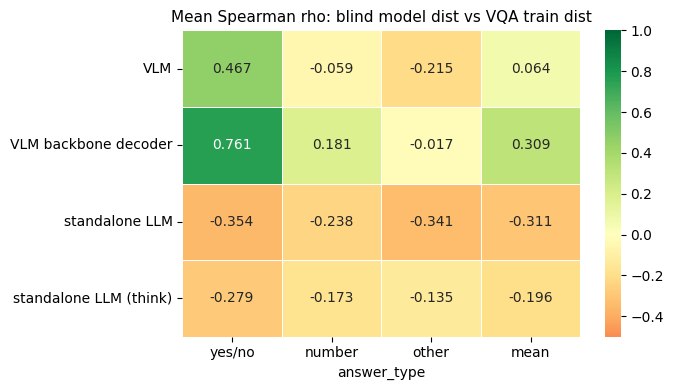


Group-mean correlations:


answer_type,yes/no,number,other,mean
group,,,,
VLM,0.467,-0.059,-0.215,0.064
VLM backbone decoder,0.761,0.181,-0.017,0.309
standalone LLM,-0.354,-0.238,-0.341,-0.311
standalone LLM (think),-0.279,-0.173,-0.135,-0.196


In [10]:
# Group-mean Spearman rho (train only)
df_train = df_corr[df_corr['corpus'] == 'train'].copy()
group_pivot = df_train.pivot_table(
    index='group', columns='answer_type', values='spearman_rho', aggfunc='mean')
group_pivot = group_pivot[['yes/no', 'number', 'other']]
group_pivot['mean'] = group_pivot.mean(axis=1)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(group_pivot, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            vmin=-0.5, vmax=1.0, ax=ax, linewidths=0.5)
ax.set_title('Mean Spearman rho: blind model dist vs VQA train dist', fontsize=11)
ax.set_ylabel('')
plt.tight_layout()
(ROOT / 'figures' / 'corpus_frequency').mkdir(parents=True, exist_ok=True)
plt.savefig(ROOT / 'figures' / 'corpus_frequency' / 'group_correlation_hm.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nGroup-mean correlations:")
display(group_pivot.round(3))

## 9. Per-question frequency exploitation test

For each of our 1K questions, check whether the model's blind answer matches the **most frequent training answer** for that specific `question_type`. This tests per-question-type frequency matching, not just global answer distributions.

In [11]:
# Build question_type -> most frequent training answer
qtype_top_answer = {}
qtype_freq = {}
for a in train_annot:
    qt = a['question_type']
    ans = a['multiple_choice_answer'].lower().strip()
    if qt not in qtype_freq:
        qtype_freq[qt] = Counter()
    qtype_freq[qt][ans] += 1

for qt, counter in qtype_freq.items():
    top_ans, top_cnt = counter.most_common(1)[0]
    total = sum(counter.values())
    qtype_top_answer[qt] = (top_ans, top_cnt / total)

print("question_type -> most frequent training answer (with probability):\n")
for qt, (ans, prob) in sorted(qtype_top_answer.items(), key=lambda x: -x[1][1])[:15]:
    print(f"  {qt:30s}  '{ans}'  ({prob:.1%})")

question_type -> most frequent training answer (with probability):

  could                           'yes'  (63.7%)
  do                              'yes'  (55.3%)
  does the                        'yes'  (53.1%)
  are there                       'yes'  (52.2%)
  does this                       'yes'  (52.0%)
  is there                        'yes'  (51.9%)
  is there a                      'yes'  (51.5%)
  do you                          'yes'  (51.4%)
  has                             'yes'  (50.5%)
  are there any                   'yes'  (50.1%)
  is he                           'no'  (50.1%)
  are                             'no'  (50.0%)
  is the man                      'no'  (49.2%)
  can you                         'no'  (49.1%)
  is the woman                    'no'  (49.1%)


In [12]:
# For each model, compute: what % of blind answers match the training-set
# most-frequent answer for that question_type?
rows = []
for model_name, (group, answers) in all_models.items():
    matches = 0
    total = 0
    for qid, ans in answers.items():
        qt = qid_to_qtype.get(qid)
        if qt and qt in qtype_top_answer:
            total += 1
            if ans == qtype_top_answer[qt][0]:
                matches += 1
    if total > 0:
        rows.append({
            'model': model_name, 'group': group,
            'freq_match_rate': matches / total,
            'n': total
        })

df_freq_match = pd.DataFrame(rows).sort_values(['group', 'freq_match_rate'], ascending=[True, False])

print("% of blind answers matching training-set most-frequent answer per question_type\n")
print(f"{'Model':40s} {'Group':12s} {'Match%':>7s}  {'n':>5s}")
print("-" * 70)
for _, row in df_freq_match.iterrows():
    print(f"  {row['model']:38s} {row['group']:12s} {row['freq_match_rate']:6.1%}  {row['n']:5.0f}")

print(f"\nGroup means:")
display(df_freq_match.groupby('group')['freq_match_rate'].agg(['mean', 'std', 'count']).round(3))

% of blind answers matching training-set most-frequent answer per question_type

Model                                    Group         Match%      n
----------------------------------------------------------------------
  Qwen3-VL-4B                            VLM           28.7%   1000
  InternVL-8B                            VLM           26.5%   1000
  Qwen3-VL-8B                            VLM           25.1%    993
  LLaVA-Vicuna-13B                       VLM           24.8%    999
  Qwen3-VL-2B                            VLM           22.9%    999
  LLaVA-Mistral                          VLM           22.7%   1000
  InternVL-1B                            VLM           22.5%    999
  Qwen3-VL-32B                           VLM           22.0%    998
  LLaVA-1.5-7B                           VLM           21.7%   1000
  LLaVA-Vicuna                           VLM           21.5%   1000
  InternVL-2B                            VLM           20.2%    999
  LLaVA-1.5 (LM)               

,mean,std,count
group,,,
VLM,0.235,0.025,11
VLM backbone decoder,0.285,0.031,11
standalone LLM,0.127,0.092,11
standalone LLM (think),0.148,0.082,5


## 10. Train vs Val comparison: are the distributions equivalent?

Quick check that train and val have similar answer distributions, so our analysis generalizes.

In [13]:
# Train vs Val answer distribution correlation
print("Train vs Val answer distribution correlation:\n")
for atype in ['yes/no', 'number', 'other']:
    t_prob = freq_to_prob(train_freq[atype])
    v_prob = freq_to_prob(val_freq[atype])
    vocab = set(list(t_prob.keys())[:50]) | set(list(v_prob.keys())[:50])
    tv = [t_prob.get(a, 0) for a in sorted(vocab)]
    vv = [v_prob.get(a, 0) for a in sorted(vocab)]
    rho, p = spearmanr(tv, vv)
    r, pr = pearsonr(tv, vv)
    print(f"  {atype:10s}  Spearman rho={rho:.4f} (p={p:.2e})  Pearson r={r:.4f} (p={pr:.2e})")

Train vs Val answer distribution correlation:

  yes/no      Spearman rho=0.1172 (p=7.47e-01)  Pearson r=1.0000 (p=1.52e-18)
  number      Spearman rho=0.9229 (p=9.61e-36)  Pearson r=0.9998 (p=9.38e-139)
  other       Spearman rho=0.9884 (p=3.43e-77)  Pearson r=0.9989 (p=9.63e-124)


## 11. Summary & Interpretation

**Key findings** (to be filled after running):

1. **Yes/No bias**: Training is ~50/50, but blind models produce ~70% "no" → bias is **not** from corpus frequency
2. **Number bias**: Training top answers are "1" (21.7%) and "2" (21.2%), "0" is only 8.4%, yet models collapse to "0" → **inverted** relative to training frequency
3. **Color/Other**: Training top is "white" (4.1%), models produce "black" (16%) → different default

**Implication**: Blind model biases are better explained as **uncertainty defaults** (negation, zero, absence) rather than corpus frequency matching. This complicates the McCoy (2024) framing — the biases are real but their mechanism is different from simple frequency exploitation.